# Лабораторная работа №1
### 6132 Казаков Павел
### Вариант 20

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import math

## 1. Считать цветное rgb изображение

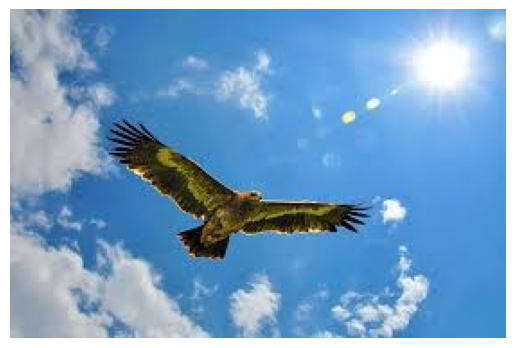

In [ ]:
img = cv2.imread("images/eagle.jpg")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## 2. Преобразовать изображение в градации серого

In [7]:
def gray(img, coef):
  return np.round(np.dot(img, coef)).astype(int)

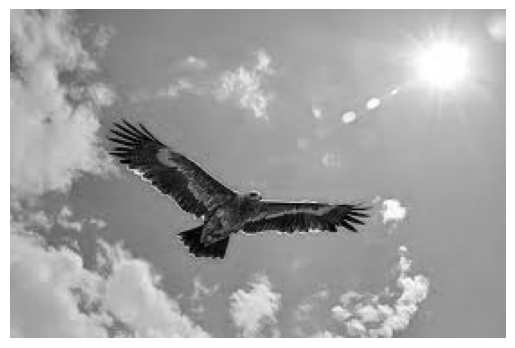

In [8]:
f = gray(img, coef=[0.2126, 0.7152, 0.0722])

plt.imshow(f, cmap="gray")
plt.axis("off")
plt.show()

## 3. Написать функцию реализации поэлементной обработки изображения

In [9]:
def elementwise(f, fun):
  g = np.empty(f.shape)
  for m in range(f.shape[0]):
    for n in range(f.shape[1]):
      g[m, n] = fun(f[m, n])
  return g

## 4. По гистограмме изображения определить значение порога яркостей, обеспечивающего оптимальное разделение объекта и фона. Осуществить пороговую обработку входного изображения с найденным пороговым значением

In [10]:
def density_distrib(f):
  Wf = np.zeros(256)
  for m in range(f.shape[0]):
    for n in range(f.shape[1]):
      Wf[int(f[m, n])] += 1
  return Wf / (f.shape[0] * f.shape[1])

In [11]:
Wf = density_distrib(f)
f0 = 90

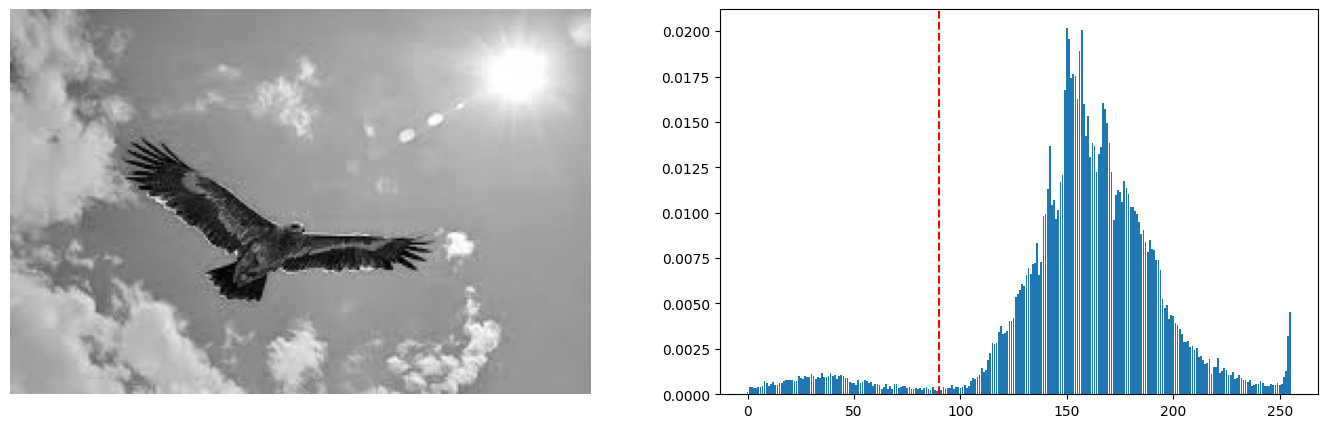

In [12]:
plt.figure(figsize=(17, 5))

plt.subplot(1, 2, 1)
plt.imshow(f, cmap="gray")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.bar(range(0, 256), Wf)
plt.axvline(x=f0, color="red", linestyle="--")

plt.show()

In [13]:
bin = lambda f: 255 if f >= f0 else 0

g = elementwise(f, bin)
Wg = density_distrib(g)

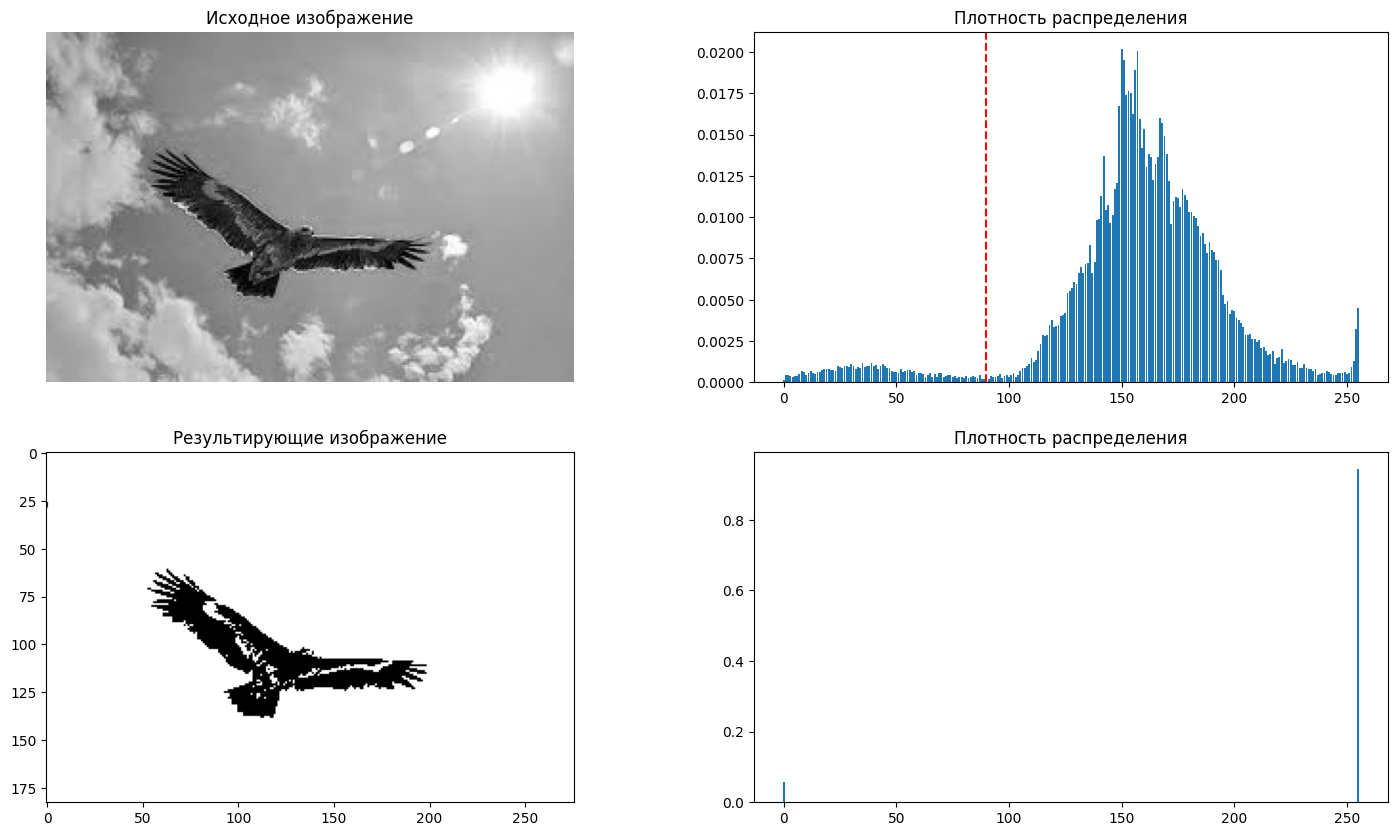

In [ ]:
plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1)
plt.imshow(f, cmap="gray")
plt.axis("off")
plt.title("Исходное изображение")
plt.subplot(2, 2, 2)
plt.bar(range(0, 256), Wf)
plt.title("Плотность распределения")
plt.axvline(x=f0, color="red", linestyle="--")

plt.subplot(2, 2, 3)
plt.imshow(g, cmap="gray")
plt.title("Результирующие изображение")
plt.subplot(2, 2, 4)
plt.bar(range(0, 256), Wg)
plt.title("Плотность распределения")

plt.show()

## 5. Сделать пороговую обработку методом Otsu (Функция OpenCV)

In [15]:
f0_ots, g_ots = cv2.threshold(f.astype(np.uint8), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
Wg_ots = density_distrib(g_ots)

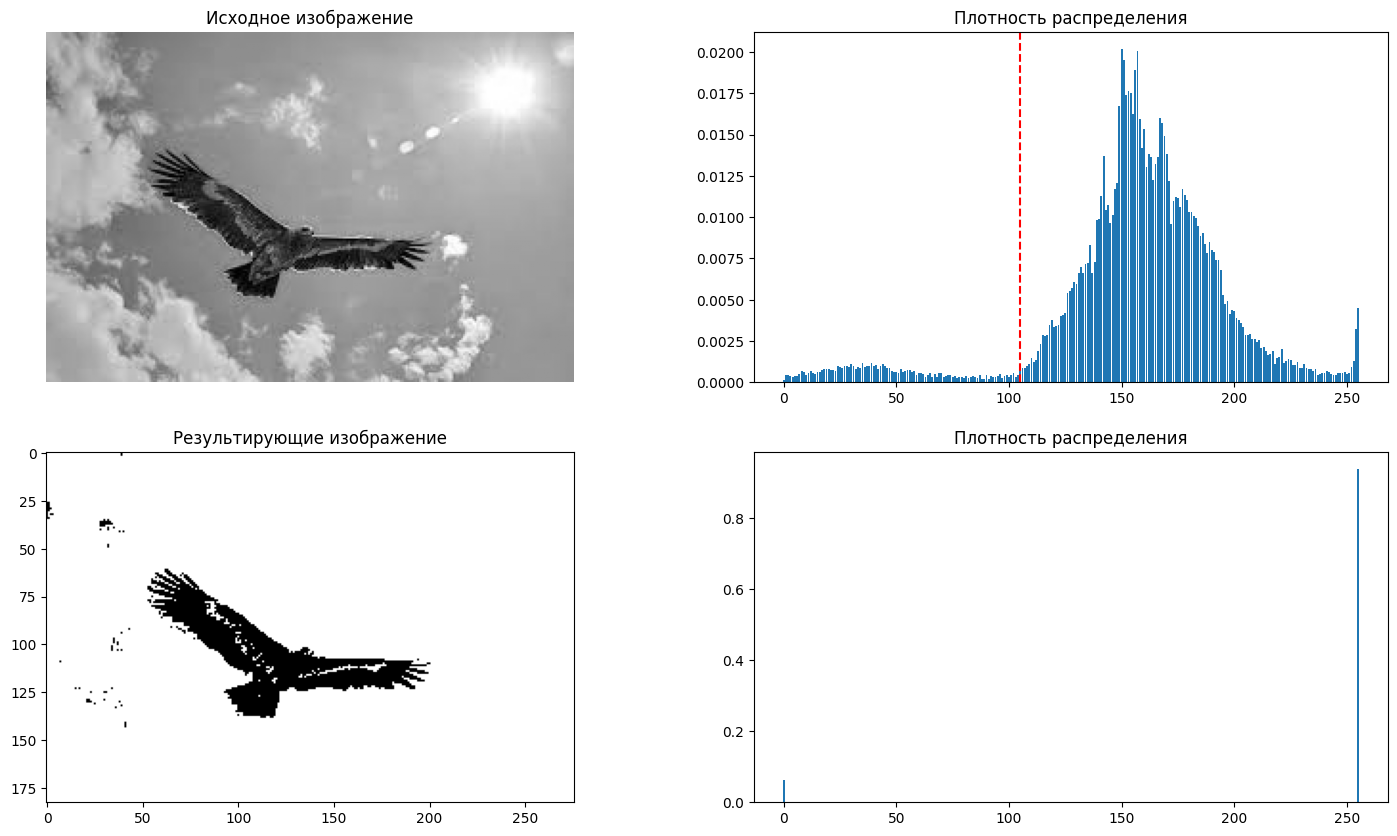

In [ ]:
plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1)
plt.imshow(f, cmap="gray")
plt.axis("off")
plt.title("Исходное изображение")
plt.subplot(2, 2, 2)
plt.bar(range(0, 256), Wf)
plt.title("Плотность распределения")
plt.axvline(x=f0_ots, color="red", linestyle="--")

plt.subplot(2, 2, 3)
plt.imshow(g_ots, cmap="gray")
plt.title("Результирующие изображение")
plt.subplot(2, 2, 4)
plt.bar(range(0, 256), Wg_ots)
plt.title("Плотность распределения")

plt.show()

## 6. Определить динамический диапазон входного изображения. Осуществить линейное контрастирование входного изображения в заданный динамический диапазон яркостей

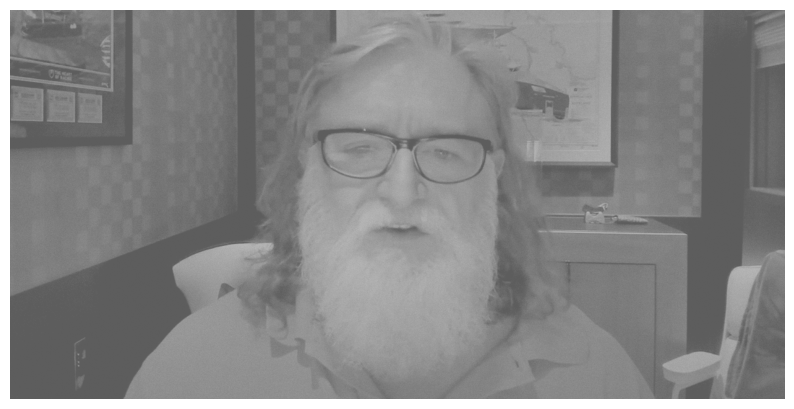

In [17]:
img2 = cv2.imread("images/gaben.png")
f2 = np.average(img2, axis=2).astype(int)

plt.figure(figsize=(10, 10))
plt.imshow(f2, cmap="gray", norm=mcolors.NoNorm())
plt.axis("off")
plt.show()

In [18]:
f2_min = np.min(f2)
f2_max = np.max(f2)

g2_min = 0
g2_max = 255

a = (g2_max - g2_min) / (f2_max - f2_min)
b = (g2_min*f2_max - g2_max*f2_min) / (f2_max - f2_min)

lin = lambda f: a*f + b

g2 = np.round(elementwise(f2, lin)).astype(int)

Wf2 = density_distrib(f2)
Wg2 = density_distrib(g2)

print(f"f_min={f2_min} f_max={f2_max}")
print(f"a={a:.3f} b={b:.3f}")
print(f"g_min={np.min(g2)} g_max={np.max(g2)}")

f_min=93 f_max=184
a=2.802 b=-260.604
g_min=0 g_max=255


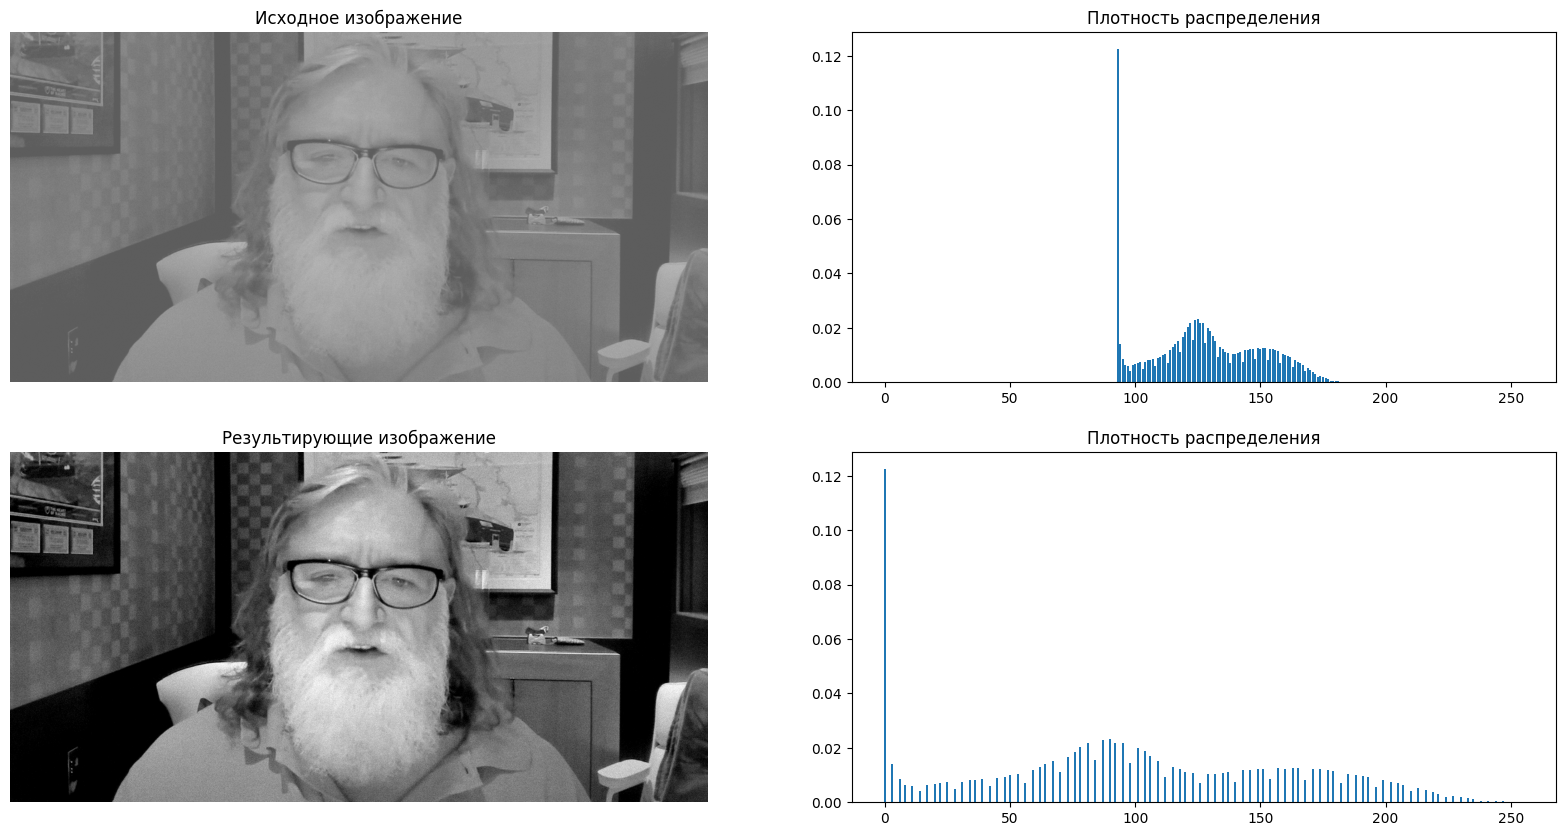

In [ ]:
plt.figure(figsize=(20, 10))

plt.subplot(2, 2, 1)
plt.imshow(f2, cmap="gray", norm=mcolors.NoNorm())
plt.axis("off")
plt.title("Исходное изображение")
plt.subplot(2, 2, 2)
plt.bar(range(0, 256), Wf2)
plt.title("Плотность распределения")

plt.subplot(2, 2, 3)
plt.imshow(g2, cmap="gray", norm=mcolors.NoNorm())
plt.axis("off")
plt.title("Результирующие изображение")
plt.subplot(2, 2, 4)
plt.bar(range(0, 256), Wg2)
plt.title("Плотность распределения")

plt.show()

## 7. Сделать эквализацию гистограммы изображения

In [20]:
def integral_distrib(Wf):
  Ff = np.empty(len(Wf))
  Ff[0] = Wf[0]
  for n in range(1, len(Wf)):
    Ff[n] = Wf[n] + Ff[n-1]
  return Ff

In [21]:
Ff = integral_distrib(Wf)

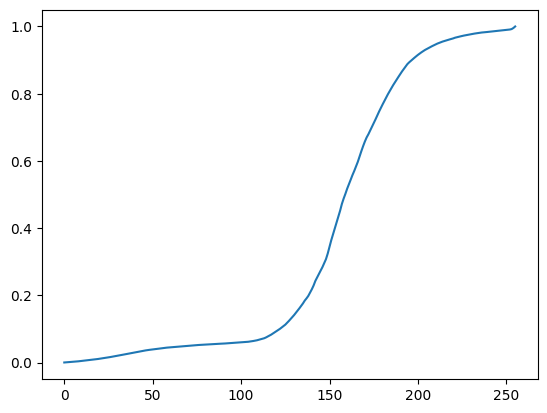

In [22]:
plt.plot(range(0, 256), Ff)
plt.show()

In [23]:
g_min_eql = 0
g_max_eql = 255

eql = lambda f: (g_max_eql - g_min_eql)*Ff[f] + g_min_eql

g_eql = elementwise(f, eql)
Wg_eql = density_distrib(g_eql)
Fg_eql = integral_distrib(Wg_eql)

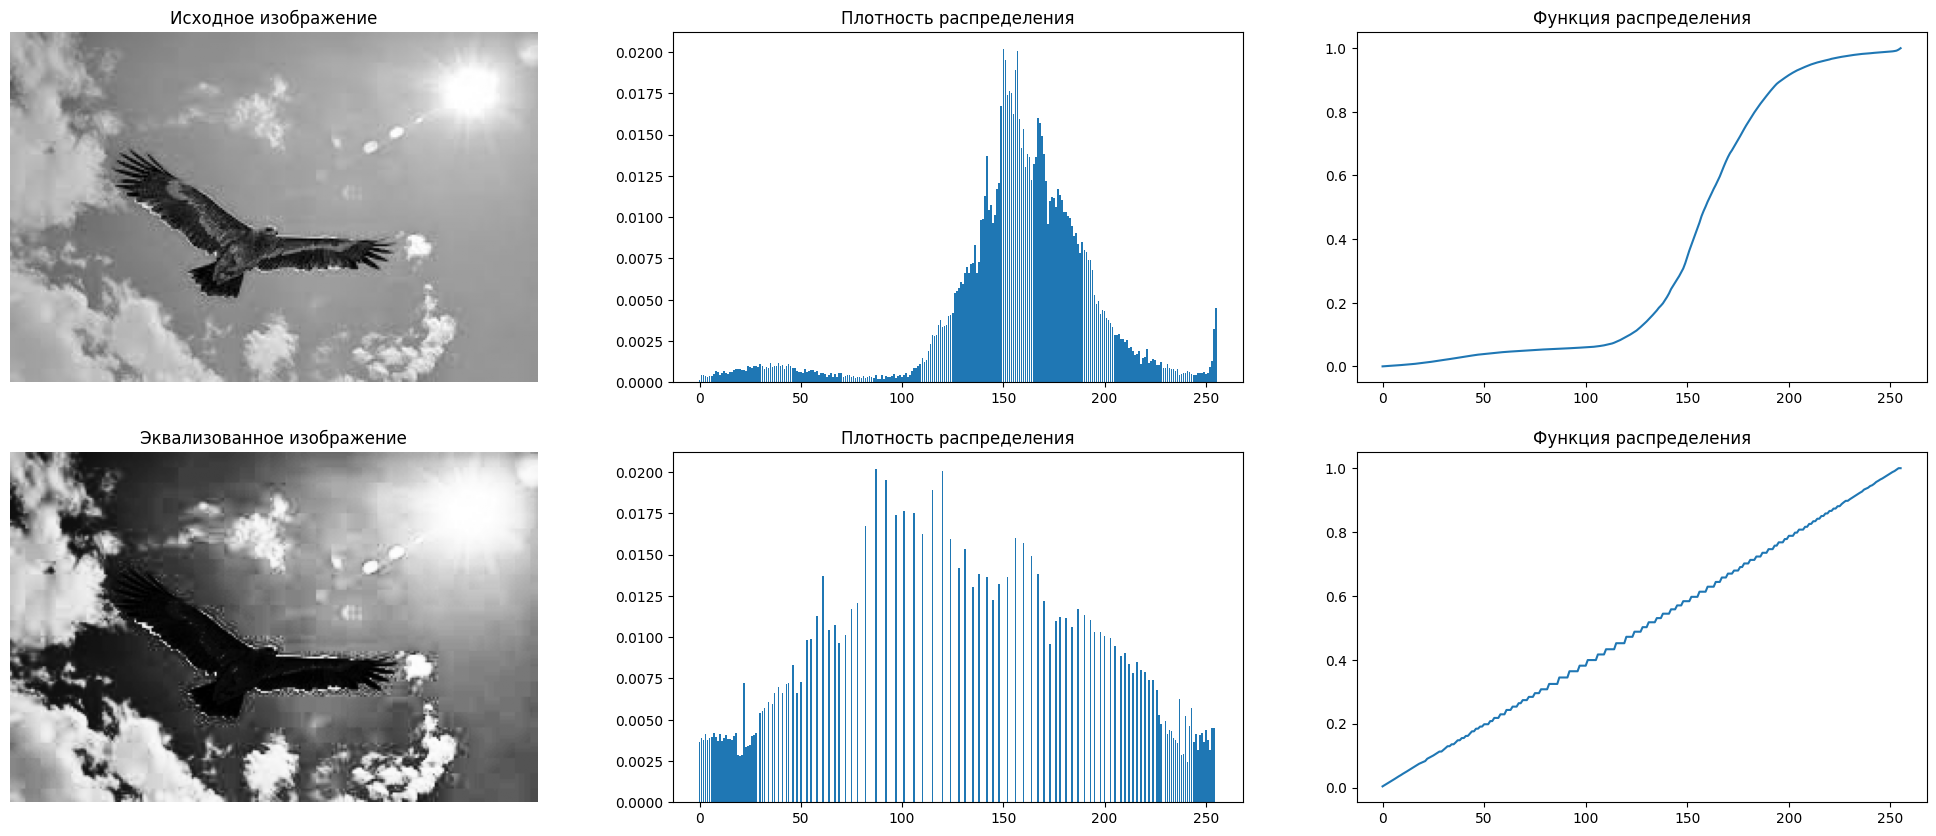

In [ ]:
plt.figure(figsize=(25, 10))

plt.subplot(2, 3, 1)
plt.imshow(f, cmap="gray")
plt.axis("off")
plt.title("Исходное изображение")
plt.subplot(2, 3, 2)
plt.bar(range(0, 256), Wf)
plt.title("Плотность распределения")
plt.subplot(2, 3, 3)
plt.plot(range(0, 256), Ff)
plt.title("Функция распределения")

plt.subplot(2, 3, 4)
plt.imshow(g_eql, cmap="gray")
plt.axis("off")
plt.title("Эквализованное изображение")
plt.subplot(2, 3, 5)
plt.bar(range(0, 256), Wg_eql)
plt.title("Плотность распределения")
plt.subplot(2, 3, 6)
plt.plot(range(0, 256), Fg_eql)
plt.title("Функция распределения")

plt.show()

## 8. Сделать эквализацию методом CLAHE (Функция OpenCV)

In [25]:
g_clh = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8)).apply(f.astype(np.uint8))
Wg_clh = density_distrib(g_clh)
Fg_clh = integral_distrib(Wg_clh)

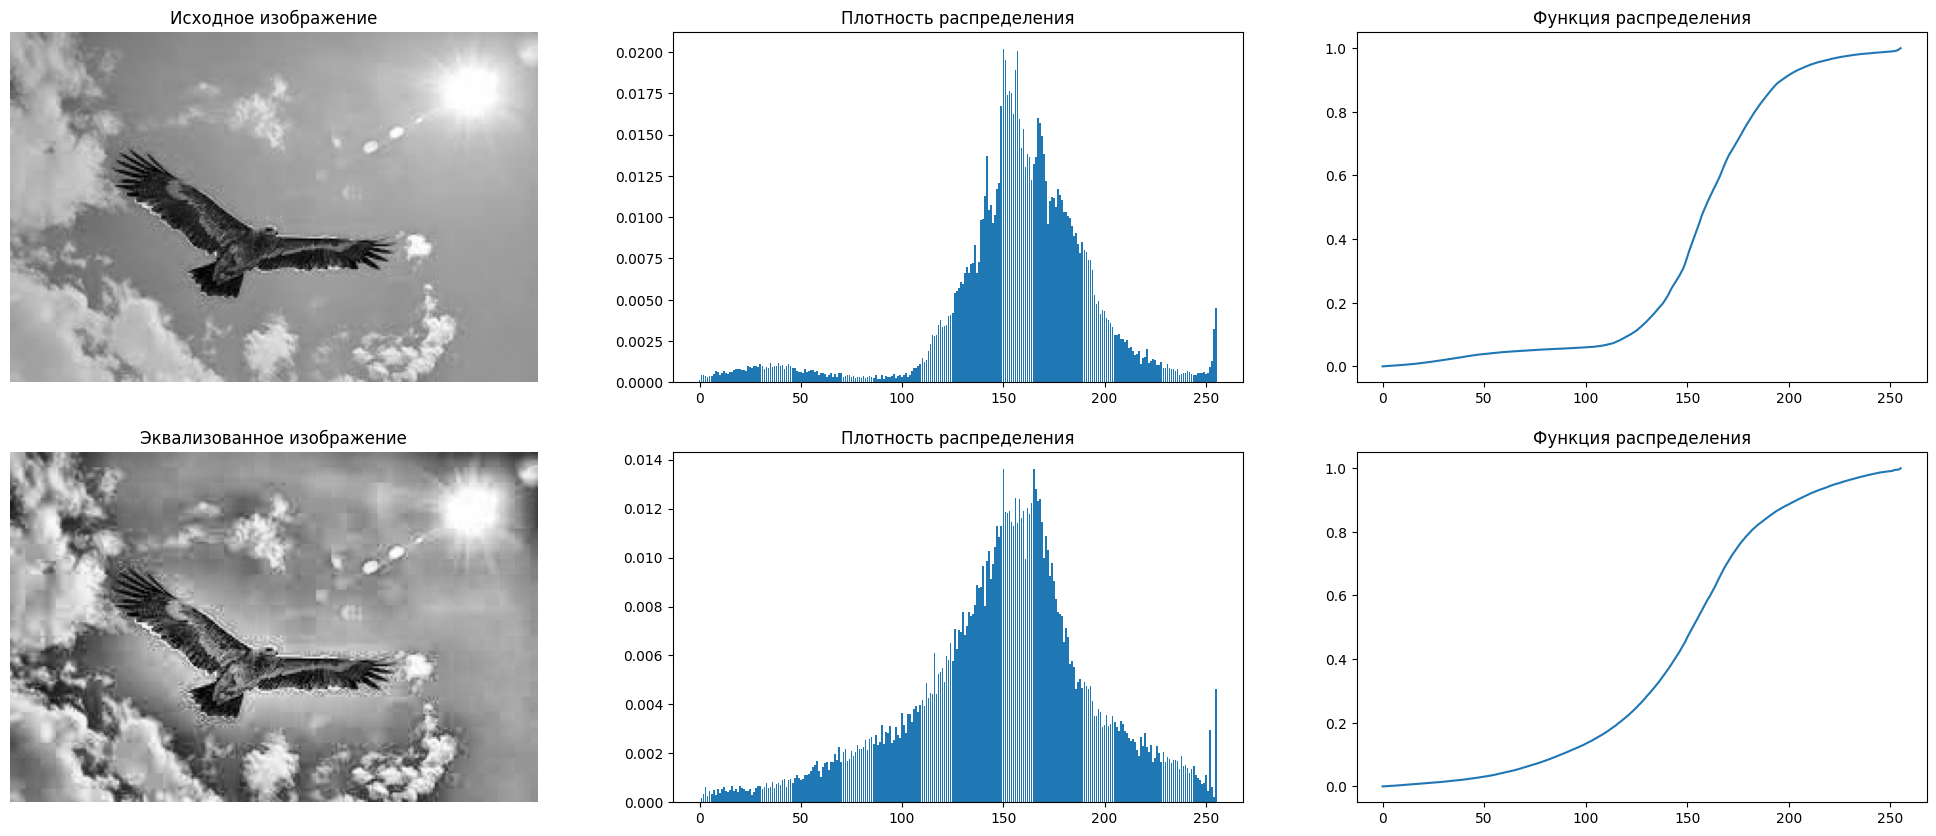

In [ ]:
plt.figure(figsize=(25, 10))

plt.subplot(2, 3, 1)
plt.imshow(f, cmap="gray")
plt.axis("off")
plt.title("Исходное изображение")
plt.subplot(2, 3, 2)
plt.bar(range(0, 256), Wf)
plt.title("Плотность распределения")
plt.subplot(2, 3, 3)
plt.plot(range(0, 256), Ff)
plt.title("Функция распределения")

plt.subplot(2, 3, 4)
plt.imshow(g_clh, cmap="gray")
plt.axis("off")
plt.title("Эквализованное изображение")
plt.subplot(2, 3, 5)
plt.bar(range(0, 256), Wg_clh)
plt.title("Плотность распределения")
plt.subplot(2, 3, 6)
plt.plot(range(0, 256), Fg_clh)
plt.title("Функция распределения")

plt.show()

## 9. Осуществить препарирование изображения с заданной препарирующей функцией

In [27]:
g_min_cus = 50
g_max_cus = 225

def custom_fun(f, f0=g_min_cus, f1=g_max_cus):
    if f < f0:
        return f0
    elif f <= f1:
        return f
    else:
        return f1

g_cus = elementwise(f, custom_fun)
Wg_cus = density_distrib(g_cus)
Fg_cus = integral_distrib(Wg_cus)

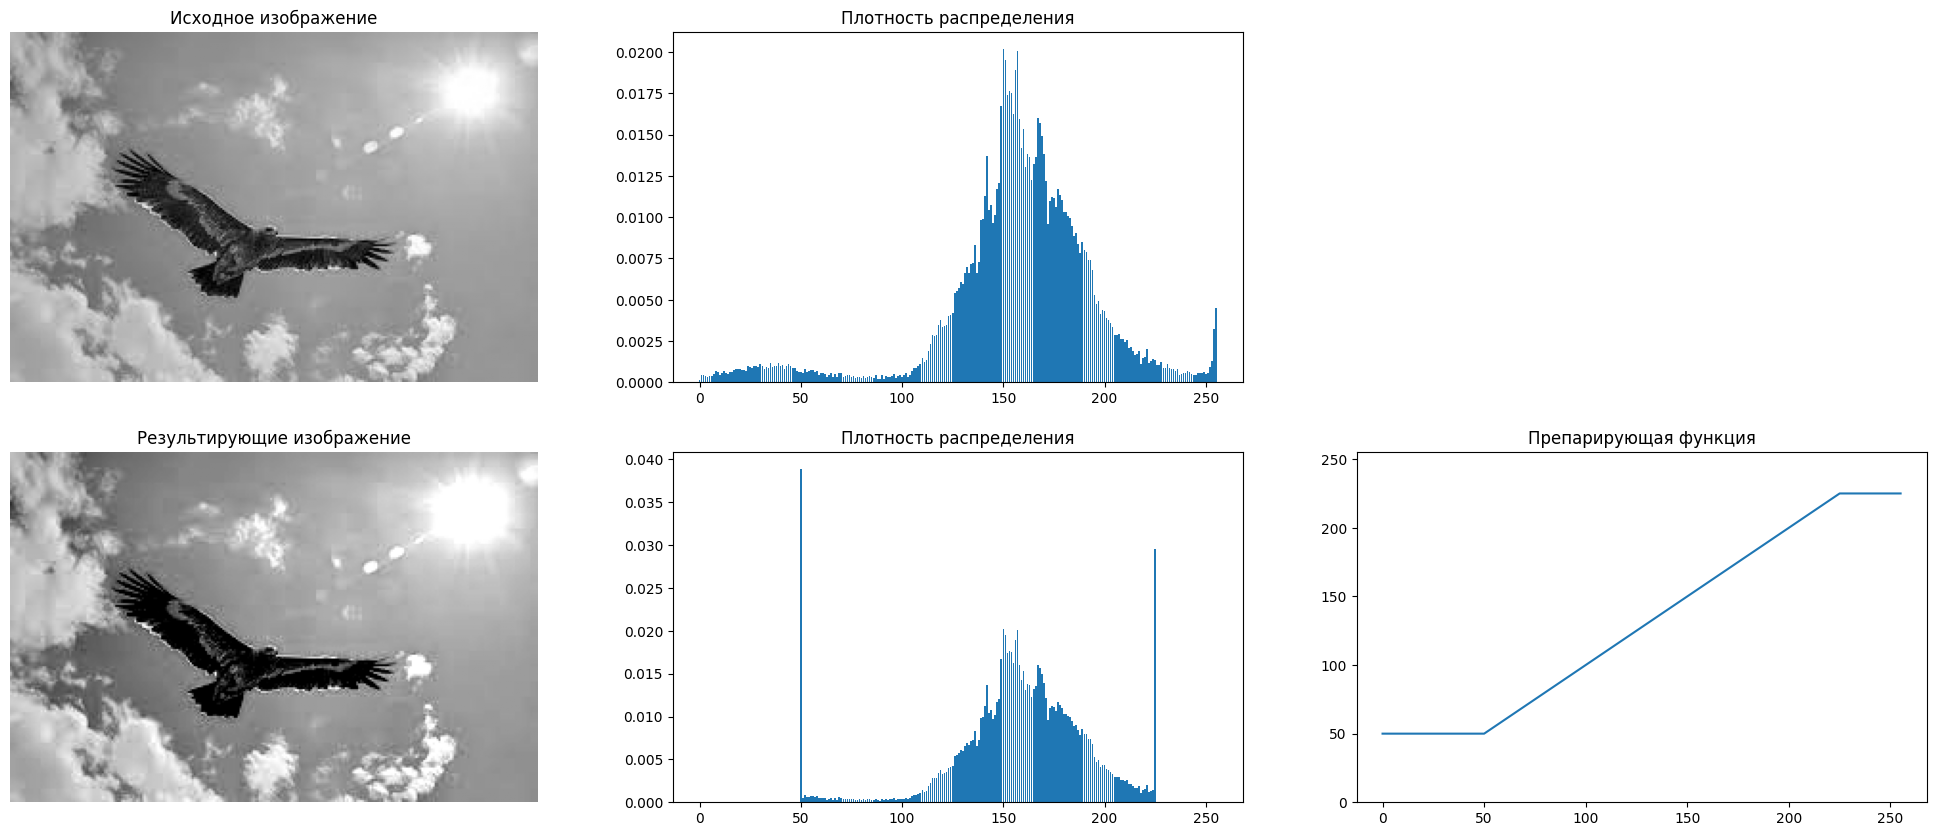

In [ ]:
plt.figure(figsize=(25, 10))

plt.subplot(2, 3, 1)
plt.imshow(f, cmap="gray")
plt.axis("off")
plt.title("Исходное изображение")
plt.subplot(2, 3, 2)
plt.bar(range(0, 256), Wf)
plt.title("Плотность распределения")

plt.subplot(2, 3, 4)
plt.imshow(g_cus, cmap="gray")
plt.axis("off")
plt.title("Результирующие изображение")
plt.subplot(2, 3, 5)
plt.bar(range(0, 256), Wg_cus)
plt.title("Плотность распределения")
plt.subplot(2, 3, 6)
plt.plot(np.vectorize(custom_fun)(range(0, 256)))
plt.ylim((0, 255))
plt.title("Препарирующая функция")

plt.show()